1. Import Libraries

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

2. Create Student Feedback Dataset

In [2]:
data = {
    "Feedback": [
        "The teacher explains concepts very clearly.",
        "The lectures are boring and difficult to understand.",
        "I really enjoy the classroom activities.",
        "The teaching speed is too fast.",
        "The teacher is helpful and supportive.",
        "There is not enough practical training.",
        "The subject content is interesting.",
        "The assignments are too difficult.",
        "The classroom environment is comfortable.",
        "The teacher should use more real-world examples.",
        "The online learning materials are very useful.",
        "The classes are too long and tiring.",
        "I am satisfied with the teaching method.",
        "More interactive activities should be included.",
        "The laboratory sessions are very helpful.",
        "The syllabus is difficult to complete on time.",
        "The teacher gives good feedback on assignments.",
        "The classroom equipment needs improvement.",
        "The subject is easy to understand.",
        "More practical sessions are required."
    ]
}

In [3]:
df = pd.DataFrame(data)
print(df.head())

                                            Feedback
0        The teacher explains concepts very clearly.
1  The lectures are boring and difficult to under...
2           I really enjoy the classroom activities.
3                    The teaching speed is too fast.
4             The teacher is helpful and supportive.


3. Preprocess Feedback Text

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [5]:
df["Clean_Feedback"] = df["Feedback"].apply(clean_text)
print(df[["Feedback", "Clean_Feedback"]].head())

                                            Feedback  \
0        The teacher explains concepts very clearly.   
1  The lectures are boring and difficult to under...   
2           I really enjoy the classroom activities.   
3                    The teaching speed is too fast.   
4             The teacher is helpful and supportive.   

                        Clean_Feedback  
0     teacher explains concept clearly  
1  lecture boring difficult understand  
2      really enjoy classroom activity  
3                  teaching speed fast  
4           teacher helpful supportive  


4. Perform Sentiment Analysis

In [6]:
def sentiment_analysis(text):

    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [7]:
df["Sentiment"] = df["Feedback"].apply(sentiment_analysis)
print(df[["Feedback", "Sentiment"]])

                                             Feedback Sentiment
0         The teacher explains concepts very clearly.  Positive
1   The lectures are boring and difficult to under...  Negative
2            I really enjoy the classroom activities.  Positive
3                     The teaching speed is too fast.  Positive
4              The teacher is helpful and supportive.  Positive
5             There is not enough practical training.   Neutral
6                 The subject content is interesting.  Positive
7                  The assignments are too difficult.  Negative
8           The classroom environment is comfortable.  Positive
9    The teacher should use more real-world examples.  Positive
10     The online learning materials are very useful.  Positive
11               The classes are too long and tiring.  Negative
12           I am satisfied with the teaching method.  Positive
13    More interactive activities should be included.  Positive
14          The laboratory sessions are 

5. Sentiment Count

In [8]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    14
Negative     4
Neutral      2
Name: count, dtype: int64


Sentiment Graph

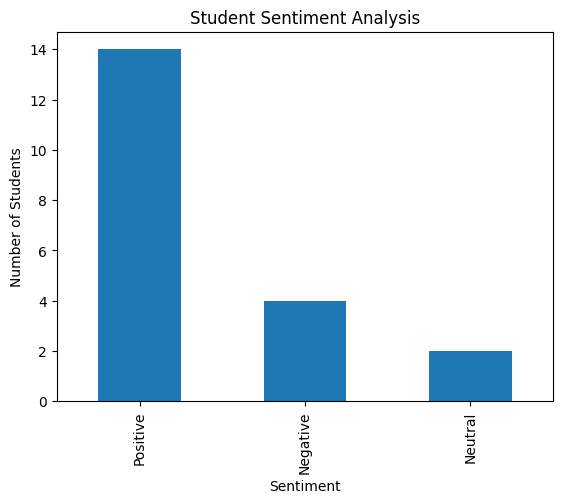

In [9]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Student Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Students")

plt.show()

6. Identify Common Student Concerns

In [10]:
concerns = [
    "difficult",
    "boring",
    "fast",
    "long",
    "tiring",
    "assignment",
    "practical",
    "equipment",
    "syllabus",
    "interactive"
]

print("Common Student Concerns:\n")
for feedback in df["Feedback"]:
    text = feedback.lower()
    if any(word in text for word in concerns):
        print(feedback)

Common Student Concerns:

The lectures are boring and difficult to understand.
The teaching speed is too fast.
There is not enough practical training.
The assignments are too difficult.
The classes are too long and tiring.
More interactive activities should be included.
The syllabus is difficult to complete on time.
The teacher gives good feedback on assignments.
The classroom equipment needs improvement.
More practical sessions are required.


7. Word Cloud

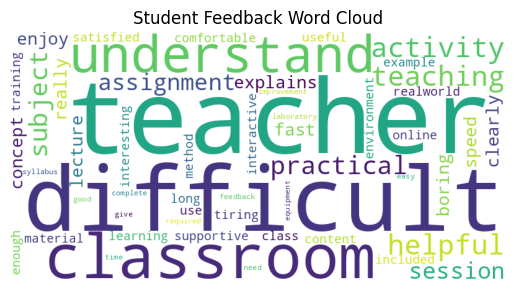

In [11]:
all_words = " ".join(df["Clean_Feedback"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Student Feedback Word Cloud")
plt.show()